# Integrated FYP Notebook (Reuse Existing Preprocessing)
This version reuses the exact preprocessing pipeline from your HBGRU GloVe notebook and runs 6 experiments.

In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, GRU, LSTM, Dense, Dropout,
    Bidirectional, GlobalMaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from tensorflow.keras.models import load_model

import pickle

from sklearn.utils.class_weight import compute_class_weight

In [13]:
# SAME PREPROCESSING AS EXISTING NOTEBOOKS

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
file_path = os.path.join(BASE_DIR, "data", "processed", "new_cleaned.csv")

df = pd.read_csv(file_path)

X = df["clean_text"].fillna("").astype(str)
y = df["sentiment"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

max_words = 20000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

word_index = tokenizer.word_index


In [3]:
print(df['sentiment'].value_counts())

sentiment
0.0    29000
1.0    28994
Name: count, dtype: int64


In [14]:
# LOAD GLOVE EMBEDDINGS

glove_index = {}
glove_path = os.path.join(BASE_DIR, "embeddings", "glove.6B.300d.txt")

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        glove_index[values[0]] = np.asarray(values[1:], dtype='float32')

# embedding_dim = 100
embedding_dim_glove = 300
# assert len(next(iter(glove_index.values()))) == embedding_dim_glove

embedding_matrix_glove = np.zeros((max_words, embedding_dim_glove))

for word, i in word_index.items():
    if i >= max_words:
        continue

    vec = glove_index.get(word)
    if vec is not None:
        embedding_matrix_glove[i] = vec


In [15]:
matched_words = 0

for word, i in tokenizer.word_index.items():
    if i >= max_words:
        continue

    vector = glove_index.get(word)

    if vector is not None:
        embedding_matrix_glove[i] = vector
        matched_words += 1

print("Matched words:", matched_words)
print("Total vocab:", len(tokenizer.word_index))
print("Coverage:", matched_words / len(tokenizer.word_index))

Matched words: 14256
Total vocab: 33328
Coverage: 0.42774843975036003


In [16]:
df['clean_text'] = df['clean_text'].fillna('').astype(str)

df = df[df['clean_text'].str.strip() != '']

In [17]:
# LOAD WORD2VEC
from gensim.models import Word2Vec

sentences = [text.split() for text in df['clean_text']]

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4
)

w2v_model.save("word2vec.model")

In [18]:
print(len(w2v_model.wv))          # vocabulary size
print(w2v_model.wv.most_similar("good"))

15462
[('decent', 0.833074688911438), ('great', 0.8200492858886719), ('ok', 0.7868945002555847), ('amazing', 0.7778330445289612), ('nice', 0.7478271126747131), ('okay', 0.7382220029830933), ('awesome', 0.7334216237068176), ('excellent', 0.7038221955299377), ('fantastic', 0.6695518493652344), ('solid', 0.6629558801651001)]


In [19]:
matched = 0
total = len(word_index)

for word in word_index:
    if word in w2v_model.wv:
        matched += 1

coverage = matched / total
print("Matched words:", matched)
print("Total vocab:", total)
print("Coverage:", coverage)

Matched words: 15236
Total vocab: 33328
Coverage: 0.4571531445031205


In [20]:
embedding_dim = w2v_model.vector_size

embedding_matrix_word2vec = np.zeros((max_words, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= max_words:
        continue

    if word in w2v_model.wv:
        embedding_matrix_word2vec[i] = w2v_model.wv[word]

In [21]:
w2v_model.wv.most_similar("happy")
w2v_model.wv.most_similar("bad")

[('horrible', 0.7014208436012268),
 ('awful', 0.688406765460968),
 ('terrible', 0.6604587435722351),
 ('chemical', 0.632488489151001),
 ('strong', 0.6210386753082275),
 ('good', 0.6016517281532288),
 ('mildew', 0.5900106430053711),
 ('mad', 0.5875709056854248),
 ('okay', 0.5863982439041138),
 ('fishy', 0.5825784802436829)]

In [28]:
def build_lstm(embedding_matrix,embedding_dim):
    return Sequential([
        Embedding(max_words, embedding_dim, weights=[embedding_matrix], trainable=False),
        LSTM(64),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

def build_gru(embedding_matrix, embedding_dim):
    return Sequential([
        Embedding(max_words, embedding_dim, weights=[embedding_matrix], trainable=False),
        GRU(64),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

def build_hbgru(embedding_matrix, embedding_dim):
    return Sequential([
        Embedding(max_words, embedding_dim, weights=[embedding_matrix], trainable=False),
        Bidirectional(GRU(64, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])


In [43]:
def run_experiment(name, model):

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=1,
        callbacks=[early_stop]
    )

    pred = (model.predict(X_test_pad) > 0.5).astype(int)

    return {
        'Experiment': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'Validation Loss': min(history.history['val_loss'])
    }


In [44]:
results = []

results.append(run_experiment('Word2Vec + LSTM', build_lstm(embedding_matrix_word2vec, embedding_dim)))

Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 176s 147ms/step - accuracy: 0.4987 - loss: 0.6932 - val_accuracy: 0.5020 - val_loss: 0.6932
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 148s 128ms/step - accuracy: 0.4982 - loss: 0.6931 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 149s 128ms/step - accuracy: 0.5029 - loss: 0.6931 - val_accuracy: 0.4980 - val_loss: 0.6932
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 150s 129ms/step - accuracy: 0.5016 - loss: 0.6931 - val_accuracy: 0.5020 - val_loss: 0.6932
363/363 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step


In [45]:
results.append(run_experiment('Word2Vec + GRU', build_gru(embedding_matrix_word2vec, embedding_dim)))

Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 151s 127ms/step - accuracy: 0.5027 - loss: 0.6932 - val_accuracy: 0.4979 - val_loss: 0.6933
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 146s 126ms/step - accuracy: 0.5024 - loss: 0.6931 - val_accuracy: 0.5020 - val_loss: 0.6932
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 147s 127ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5020 - val_loss: 0.6932
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 145s 125ms/step - accuracy: 0.4969 - loss: 0.6931 - val_accuracy: 0.5020 - val_loss: 0.6932
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 146s 126ms/step - accuracy: 0.4993 - loss: 0.6930 - val_accuracy: 0.5020 - val_loss: 0.6932
363/363 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step


In [46]:
results.append(run_experiment('Word2Vec + HBGRU', build_hbgru(embedding_matrix_word2vec, embedding_dim)))

Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 208s 175ms/step - accuracy: 0.7619 - loss: 0.4928 - val_accuracy: 0.8134 - val_loss: 0.4076
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 207s 178ms/step - accuracy: 0.8199 - loss: 0.4106 - val_accuracy: 0.8306 - val_loss: 0.3825
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 215s 185ms/step - accuracy: 0.8332 - loss: 0.3880 - val_accuracy: 0.8373 - val_loss: 0.3683
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 200s 172ms/step - accuracy: 0.8380 - loss: 0.3745 - val_accuracy: 0.8425 - val_loss: 0.3593
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 196s 169ms/step - accuracy: 0.8438 - loss: 0.3631 - val_accuracy: 0.8475 - val_loss: 0.3526
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 203s 175ms/step - accuracy: 0.8469 - loss: 0.3559 - val_accuracy: 0.8500 - val_loss: 0.3494
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 212s 183ms/step - accuracy: 0.8493 - loss: 0.3501 - val_accuracy: 0.8513 - val_loss: 0.3415
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 222s 192ms/step - ac

In [47]:
results.append(run_experiment('GloVe + LSTM', build_lstm(embedding_matrix_word2vec, embedding_dim_glove)))

Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 141s 119ms/step - accuracy: 0.4989 - loss: 0.6932 - val_accuracy: 0.5019 - val_loss: 0.6932
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 138s 119ms/step - accuracy: 0.4958 - loss: 0.6932 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 142s 122ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 137s 118ms/step - accuracy: 0.4982 - loss: 0.6931 - val_accuracy: 0.5020 - val_loss: 0.6932
363/363 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step


In [48]:
results.append(run_experiment('GloVe + GRU', build_gru(embedding_matrix_word2vec, embedding_dim_glove)))

Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 148s 125ms/step - accuracy: 0.5002 - loss: 0.6932 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 149s 128ms/step - accuracy: 0.4999 - loss: 0.6931 - val_accuracy: 0.4979 - val_loss: 0.6933
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 196s 123ms/step - accuracy: 0.4974 - loss: 0.6931 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 146s 126ms/step - accuracy: 0.4980 - loss: 0.6931 - val_accuracy: 0.4979 - val_loss: 0.6933
363/363 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step


In [49]:
results.append(run_experiment('GloVe + HBGRU', build_hbgru(embedding_matrix_word2vec, embedding_dim_glove)))

Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 214s 180ms/step - accuracy: 0.7698 - loss: 0.4835 - val_accuracy: 0.8181 - val_loss: 0.4024
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 257s 175ms/step - accuracy: 0.8200 - loss: 0.4076 - val_accuracy: 0.8333 - val_loss: 0.3785
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 236s 204ms/step - accuracy: 0.8317 - loss: 0.3848 - val_accuracy: 0.8418 - val_loss: 0.3638
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 244s 210ms/step - accuracy: 0.8385 - loss: 0.3727 - val_accuracy: 0.8414 - val_loss: 0.3560
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 247s 213ms/step - accuracy: 0.8434 - loss: 0.3620 - val_accuracy: 0.8446 - val_loss: 0.3491
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 248s 213ms/step - accuracy: 0.8476 - loss: 0.3532 - val_accuracy: 0.8514 - val_loss: 0.3427
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 246s 212ms/step - accuracy: 0.8494 - loss: 0.3481 - val_accuracy: 0.8507 - val_loss: 0.3415
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 248s 214ms/step - ac

In [50]:
results_df = pd.DataFrame(results)
results_df

,Experiment,Accuracy,Precision,Recall,F1,Validation Loss
0,Word2Vec + LSTM,0.500216,0.625000,0.000862,0.001722,0.693157
1,Word2Vec + GRU,0.500129,0.600000,0.000517,0.001034,0.693198
2,Word2Vec + HBGRU,0.862919,0.873337,0.848939,0.860965,0.320787
3,GloVe + LSTM,0.500388,0.833333,0.000862,0.001723,0.693159
4,GloVe + GRU,0.499957,0.499957,1.000000,0.666628,0.693199
5,GloVe + HBGRU,0.862661,0.878646,0.841524,0.859685,0.319796


In [53]:
print(results_df.columns)

Index(['Experiment', 'Accuracy', 'Precision', 'Recall', 'F1',
       'Validation Loss'],
      dtype='object')


W2V/GloVe + HBGRU shows the highest accuracy. Further fine-tuning

In [30]:
def run_experiment_refined(name, model):

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=1,
        callbacks=[early_stop]
    )

    y_prob = model.predict(X_test_pad).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    return {
        'Experiment': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Validation Loss': min(history.history['val_loss']),
        'y_prob': y_prob,
        'y_pred': y_pred,
        'model': model
    }

In [23]:
results_new = []
predictions = {}

In [57]:
# Word2Vec + HBGRU
result = run_experiment_refined(
    'Word2Vec + HBGRU',
    build_hbgru(embedding_matrix_word2vec, embedding_dim)
)

predictions['Word2Vec + HBGRU'] = {
    'y_prob': result.pop('y_prob'),
    'y_pred': result.pop('y_pred')
}

results_new.append(result)

Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 294s 244ms/step - accuracy: 0.7605 - loss: 0.4937 - val_accuracy: 0.8125 - val_loss: 0.4111
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 247s 213ms/step - accuracy: 0.8185 - loss: 0.4101 - val_accuracy: 0.8299 - val_loss: 0.3841
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 249s 215ms/step - accuracy: 0.8299 - loss: 0.3889 - val_accuracy: 0.8380 - val_loss: 0.3691
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 274s 236ms/step - accuracy: 0.8380 - loss: 0.3748 - val_accuracy: 0.8421 - val_loss: 0.3595
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 260s 224ms/step - accuracy: 0.8434 - loss: 0.3642 - val_accuracy: 0.8441 - val_loss: 0.3559
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 260s 224ms/step - accuracy: 0.8455 - loss: 0.3549 - val_accuracy: 0.8466 - val_loss: 0.3475
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 260s 224ms/step - accuracy: 0.8500 - loss: 0.3506 - val_accuracy: 0.8459 - val_loss: 0.3514
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 255s 220ms/step - ac

In [58]:
# GloVe + HBGRU
result = run_experiment_refined(
    'GloVe + HBGRU',
    build_hbgru(embedding_matrix_glove, embedding_dim_glove)
)

predictions['GloVe + HBGRU'] = {
    'y_prob': result.pop('y_prob'),
    'y_pred': result.pop('y_pred')
}

results_new.append(result)

Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 249s 209ms/step - accuracy: 0.7116 - loss: 0.5570 - val_accuracy: 0.8068 - val_loss: 0.4301
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 238s 205ms/step - accuracy: 0.8051 - loss: 0.4336 - val_accuracy: 0.8215 - val_loss: 0.3932
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 235s 202ms/step - accuracy: 0.8250 - loss: 0.3989 - val_accuracy: 0.8335 - val_loss: 0.3701
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 238s 205ms/step - accuracy: 0.8371 - loss: 0.3761 - val_accuracy: 0.8396 - val_loss: 0.3579
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 243s 210ms/step - accuracy: 0.8442 - loss: 0.3620 - val_accuracy: 0.8477 - val_loss: 0.3423
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 241s 208ms/step - accuracy: 0.8514 - loss: 0.3466 - val_accuracy: 0.8526 - val_loss: 0.3351
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 236s 203ms/step - accuracy: 0.8563 - loss: 0.3368 - val_accuracy: 0.8563 - val_loss: 0.3292
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 237s 204ms/step - ac

In [59]:
# Summary table
results_df = pd.DataFrame(results_new)

In [60]:
cm_w2v = confusion_matrix(
    y_test,
    predictions['Word2Vec + HBGRU']['y_pred']
)

cm_glove = confusion_matrix(
    y_test,
    predictions['GloVe + HBGRU']['y_pred']
)

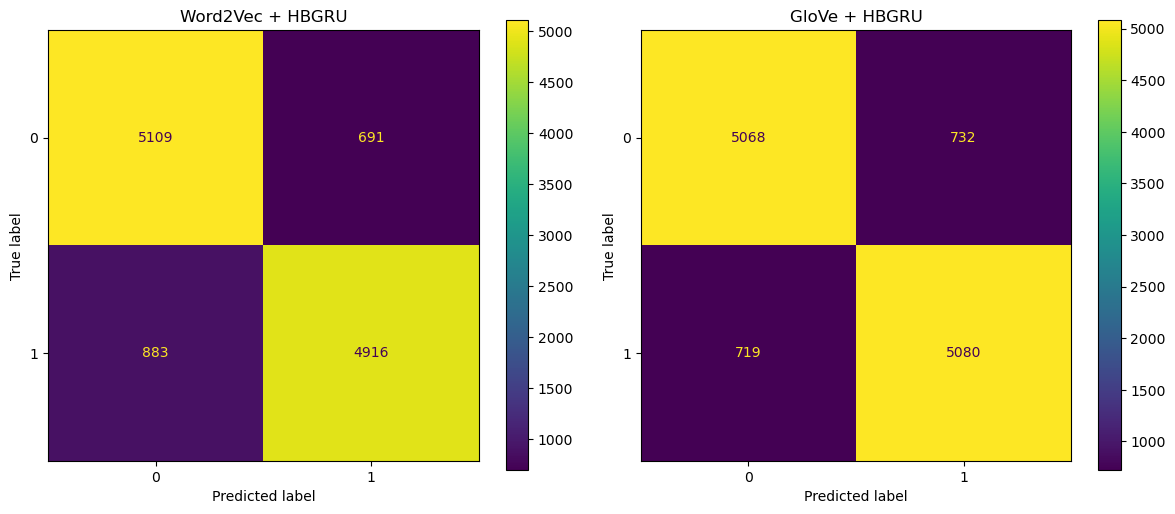

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions['Word2Vec + HBGRU']['y_pred'],
    ax=axes[0]
)
axes[0].set_title('Word2Vec + HBGRU')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions['GloVe + HBGRU']['y_pred'],
    ax=axes[1]
)
axes[1].set_title('GloVe + HBGRU')

plt.tight_layout()
plt.show()

In [64]:
auc_w2v = roc_auc_score(
    y_test,
    predictions['Word2Vec + HBGRU']['y_prob']
)

auc_glove = roc_auc_score(
    y_test,
    predictions['GloVe + HBGRU']['y_prob']
)

print(f"Word2Vec + HBGRU AUC: {auc_w2v:.4f}")
print(f"GloVe + HBGRU AUC: {auc_glove:.4f}")

Word2Vec + HBGRU AUC: 0.9378
GloVe + HBGRU AUC: 0.9419


Select GloVe + HBGRU for Higher AUC, Lower Validation Loss, Nearly identical Accuracy/F1, uses a standard embedding

Testing GloVe + HBGRU

In [69]:
def build_hbgru_glove(embedding_matrix, embedding_dim):
    return Sequential([
        Embedding(
            max_words,
            embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=True
        ),
        Bidirectional(GRU(64, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

Test Dropout 0.3, 128 GRU units, increase dense capacities, freezing embeddings

In [34]:
def build_hbgru_glove_v1(embedding_matrix, embedding_dim):
    return Sequential([
        Embedding(
            max_words,
            embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=True
        ),
        Bidirectional(GRU(64, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

def build_hbgru_glove_v2(embedding_matrix, embedding_dim):
    return Sequential([
        Embedding(
            max_words,
            embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=True
        ),
        Bidirectional(GRU(128, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

def build_hbgru_glove_v3(embedding_matrix, embedding_dim):
    return Sequential([
        Embedding(
            max_words,
            embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=True
        ),
        Bidirectional(GRU(128, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

def build_hbgru_glove_v4(embedding_matrix, embedding_dim):
    return Sequential([
        Embedding(
            max_words,
            embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False
        ),
        Bidirectional(GRU(128, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

In [25]:
results_hbgru_glove = []
predictions_hbgru_glove = {}

In [ ]:
result = run_experiment_refined(
    'GloVe_HBGRU_baseline',
    build_hbgru_glove(embedding_matrix_glove, embedding_dim_glove)
)

predictions_hbgru_glove['GloVe_HBGRU_baseline'] = {
    'y_prob': result.pop('y_prob'),
    'y_pred': result.pop('y_pred')
}

results_hbgru_glove.append(result)

# results_df_1 = pd.DataFrame(results_hbgru_glove)

Epoch 1/20


c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1160/1160 ━━━━━━━━━━━━━━━━━━━━ 325s 275ms/step - accuracy: 0.7155 - loss: 0.5461 - val_accuracy: 0.8247 - val_loss: 0.3958
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 373s 321ms/step - accuracy: 0.8315 - loss: 0.3859 - val_accuracy: 0.8510 - val_loss: 0.3450
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 372s 321ms/step - accuracy: 0.8574 - loss: 0.3401 - val_accuracy: 0.8588 - val_loss: 0.3270
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 358s 309ms/step - accuracy: 0.8734 - loss: 0.3081 - val_accuracy: 0.8615 - val_loss: 0.3279
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 360s 310ms/step - accuracy: 0.8851 - loss: 0.2863 - val_accuracy: 0.8655 - val_loss: 0.3174
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 359s 309ms/step - accuracy: 0.8945 - loss: 0.2643 - val_accuracy: 0.8658 - val_loss: 0.3203
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 357s 307ms/step - accuracy: 0.9026 - loss: 0.2446 - val_accuracy: 0.8651 - val_loss: 0.3298
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 368s 317ms/step - accuracy: 0.9

In [74]:
result = run_experiment_refined(
    'GloVe_HBGRU_v1_dropout03',
    build_hbgru_glove_v1(embedding_matrix_glove, embedding_dim_glove)
)

predictions_hbgru_glove['GloVe_HBGRU_v1_dropout03'] = {
    'y_prob': result.pop('y_prob'),
    'y_pred': result.pop('y_pred')
}

results_hbgru_glove.append(result)

# results_df_2 = pd.DataFrame(results_hbgru_glove)

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 303s 257ms/step - accuracy: 0.7435 - loss: 0.5142 - val_accuracy: 0.8291 - val_loss: 0.3845
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 366s 316ms/step - accuracy: 0.8408 - loss: 0.3680 - val_accuracy: 0.8507 - val_loss: 0.3410
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 356s 307ms/step - accuracy: 0.8648 - loss: 0.3201 - val_accuracy: 0.8632 - val_loss: 0.3230
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 360s 311ms/step - accuracy: 0.8829 - loss: 0.2899 - val_accuracy: 0.8668 - val_loss: 0.3169
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 358s 309ms/step - accuracy: 0.8935 - loss: 0.2641 - val_accuracy: 0.8693 - val_loss: 0.3158
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 359s 309ms/step - accuracy: 0.9044 - loss: 0.2442 - val_accuracy: 0.8700 - val_loss: 0.3198
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 373s 321ms/step - accuracy: 0.9122 - loss: 0.2262 - val_accuracy: 0.8697 - val_loss: 0.3255
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 360s 310ms/step - ac

In [78]:
result = run_experiment_refined(
    'GloVe_HBGRU_v2_gru128',
    build_hbgru_glove_v2(embedding_matrix_glove, embedding_dim_glove)
)

predictions_hbgru_glove['GloVe_HBGRU_v2_gru128'] = {
    'y_prob': result.pop('y_prob'),
    'y_pred': result.pop('y_pred')
}

results_hbgru_glove.append(result)

# results_df_3 = pd.DataFrame(results_hbgru_glove)

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 654s 559ms/step - accuracy: 0.7750 - loss: 0.4688 - val_accuracy: 0.8403 - val_loss: 0.3632
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 694s 599ms/step - accuracy: 0.8490 - loss: 0.3476 - val_accuracy: 0.8570 - val_loss: 0.3307
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 693s 598ms/step - accuracy: 0.8723 - loss: 0.3058 - val_accuracy: 0.8658 - val_loss: 0.3143
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 705s 608ms/step - accuracy: 0.8855 - loss: 0.2791 - val_accuracy: 0.8668 - val_loss: 0.3118
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 701s 604ms/step - accuracy: 0.8990 - loss: 0.2548 - val_accuracy: 0.8710 - val_loss: 0.3098
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 686s 592ms/step - accuracy: 0.9076 - loss: 0.2326 - val_accuracy: 0.8650 - val_loss: 0.3176
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 705s 607ms/step - accuracy: 0.9179 - loss: 0.2126 - val_accuracy: 0.8664 - val_loss: 0.3194
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 699s 602ms/step - ac

In [ ]:
result = run_experiment_refined(
    'GloVe_HBGRU_v3_dense64',
    build_hbgru_glove_v3(embedding_matrix_glove, embedding_dim_glove)
)

predictions_hbgru_glove['GloVe_HBGRU_v3_dense64'] = {
    'y_prob': result.pop('y_prob'),
    'y_pred': result.pop('y_pred')
}

results_hbgru_glove.append(result)

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 705s 595ms/step - accuracy: 0.7749 - loss: 0.4707 - val_accuracy: 0.8382 - val_loss: 0.3647
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 801s 690ms/step - accuracy: 0.8499 - loss: 0.3480 - val_accuracy: 0.8566 - val_loss: 0.3279
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 819s 706ms/step - accuracy: 0.8706 - loss: 0.3069 - val_accuracy: 0.8651 - val_loss: 0.3153
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 738s 636ms/step - accuracy: 0.8862 - loss: 0.2778 - val_accuracy: 0.8684 - val_loss: 0.3115
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 663s 572ms/step - accuracy: 0.8993 - loss: 0.2529 - val_accuracy: 0.8693 - val_loss: 0.3124
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 662s 571ms/step - accuracy: 0.9096 - loss: 0.2296 - val_accuracy: 0.8692 - val_loss: 0.3224
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 651s 561ms/step - accuracy: 0.9188 - loss: 0.2092 - val_accuracy: 0.8687 - val_loss: 0.3229
363/363 ━━━━━━━━━━━━━━━━━━━━ 52s 142ms/step


In [ ]:
results_df = pd.DataFrame(results_hbgru_glove)
print(results_df)

                 Experiment  Accuracy  Precision    Recall        F1  \
0      GloVe_HBGRU_baseline  0.867575   0.873096  0.860148  0.866574   
1  GloVe_HBGRU_v1_dropout03  0.871627   0.891107  0.846698  0.868335   
2     GloVe_HBGRU_v2_gru128  0.871972   0.889491  0.849457  0.869013   
3    GloVe_HBGRU_v3_dense64  0.867661   0.864444  0.872047  0.868229   

   Validation Loss  
0         0.317362  
1         0.315843  
2         0.309846  
3         0.311520  


Save current model

In [39]:
model_v2 = build_hbgru_glove_v2(embedding_matrix_glove, embedding_dim_glove)

model_v2_result = run_experiment_refined(
    'GloVe_HBGRU_v2',
    model_v2
)

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 682s 579ms/step - accuracy: 0.7746 - loss: 0.4718 - val_accuracy: 0.8331 - val_loss: 0.3729
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 717s 618ms/step - accuracy: 0.8503 - loss: 0.3469 - val_accuracy: 0.8556 - val_loss: 0.3370
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 713s 614ms/step - accuracy: 0.8723 - loss: 0.3060 - val_accuracy: 0.8623 - val_loss: 0.3158
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 697s 601ms/step - accuracy: 0.8878 - loss: 0.2769 - val_accuracy: 0.8633 - val_loss: 0.3135
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 693s 598ms/step - accuracy: 0.8993 - loss: 0.2515 - val_accuracy: 0.8676 - val_loss: 0.3131
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 692s 597ms/step - accuracy: 0.9090 - loss: 0.2312 - val_accuracy: 0.8702 - val_loss: 0.3187
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 708s 611ms/step - accuracy: 0.9185 - loss: 0.2112 - val_accuracy: 0.8621 - val_loss: 0.3366
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 712s 614ms/step - ac

In [40]:
print(model_v2_result['Accuracy'])
print(model_v2_result['F1'])

0.8721441503577895
0.872166192569606


In [41]:
model_v2.save('hbgru_glove_v2.keras')

loaded_model = load_model('hbgru_glove_v2.keras')

loaded_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 300, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 300, 256)       │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,015,493 (72.54 MB)

 Trainable params: 6,338,497 (24.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,676,996 (48.36 MB)

In [ ]:
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [35]:
model_v4 = build_hbgru_glove_v4(embedding_matrix_glove, embedding_dim_glove)

model_v4_result = run_experiment_refined(
    'GloVe_HBGRU_v4_frozen',
    model_v4
)

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 551s 467ms/step - accuracy: 0.7600 - loss: 0.4946 - val_accuracy: 0.8156 - val_loss: 0.4053
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 608s 524ms/step - accuracy: 0.8253 - loss: 0.3939 - val_accuracy: 0.8383 - val_loss: 0.3623
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 598s 516ms/step - accuracy: 0.8427 - loss: 0.3595 - val_accuracy: 0.8483 - val_loss: 0.3426
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 610s 526ms/step - accuracy: 0.8550 - loss: 0.3360 - val_accuracy: 0.8525 - val_loss: 0.3332
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 588s 507ms/step - accuracy: 0.8645 - loss: 0.3168 - val_accuracy: 0.8584 - val_loss: 0.3234
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 588s 506ms/step - accuracy: 0.8712 - loss: 0.3023 - val_accuracy: 0.8638 - val_loss: 0.3180
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 564s 486ms/step - accuracy: 0.8778 - loss: 0.2893 - val_accuracy: 0.8649 - val_loss: 0.3110
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 508s 438ms/step - ac

In [36]:
print(model_v4_result['Accuracy'])
print(model_v4_result['F1'])

0.8702474351237176
0.8706933585359568


In [37]:
model_v4.save('hbgru_glove_v4.keras')

loaded_model = load_model('hbgru_glove_v2.keras')

loaded_model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 300, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 300, 256)       │       330,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_10         │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,015,493 (72.54 MB)

 Trainable params: 6,338,497 (24.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,676,996 (48.36 MB)

In [38]:
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)